## Q1(a) Dataset Understanding
### Import Dataset

In [1]:
import pandas as pd

In [2]:
df = pd.read_excel("Telco_customer_churn.xlsx")

In [3]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

## Q1(b) Exploratory Data Analysis (EDA)

### Distribution Analysis
Histogram of Monthly Charges

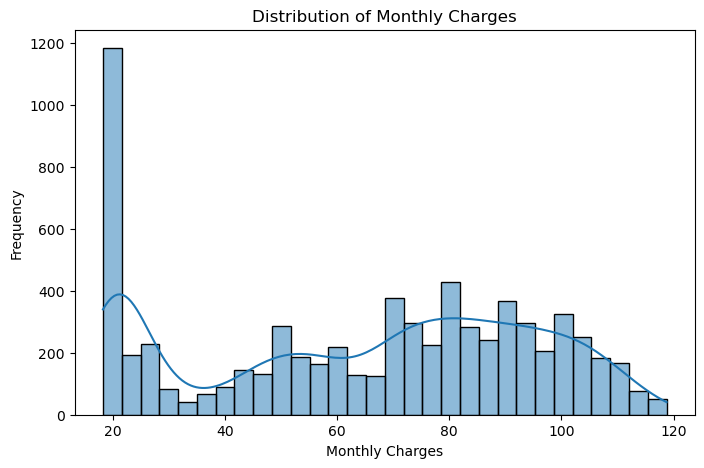

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['Monthly Charges'], bins=30, kde=True)

plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Frequency')

plt.show()

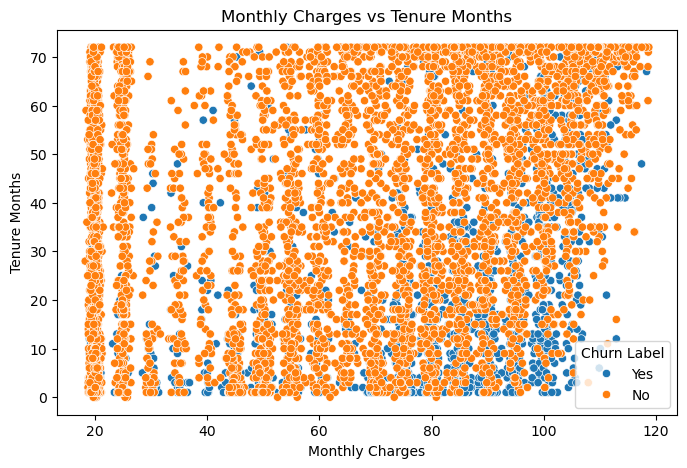

In [6]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Monthly Charges',
    y='Tenure Months',
    hue='Churn Label'
)

plt.title('Monthly Charges vs Tenure Months')
plt.xlabel('Monthly Charges')
plt.ylabel('Tenure Months')

plt.show()

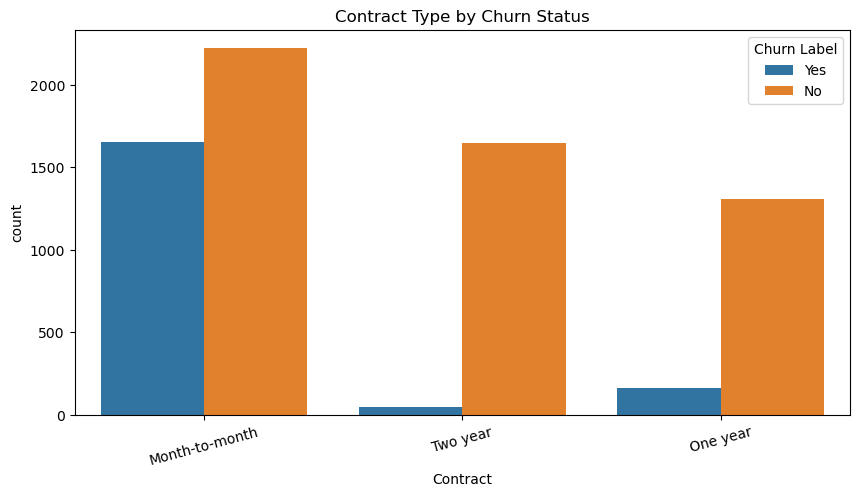

In [7]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='Contract',
    hue='Churn Label'
)

plt.title('Contract Type by Churn Status')
plt.xticks(rotation=15)

plt.show()

## Q1(c) Data Quality Checks

### Check 1: Missing Values

In [8]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

# Q2. Model Development

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

df['Total Charges'] = ...

## Q2(a) Feature Engineering

### Step 1: Convert Total Charges to Numeric

In [11]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [12]:
# Remove rows where Total Charges is missing
df = df.dropna(subset=['Total Charges']).copy()

In [13]:
# Target variable
y = df['Churn Label']

In [14]:
X = df.drop(columns=[
    'CustomerID',
    'Count',
    'Churn Label',
    'Churn Value',
    'Churn Score',
    'CLTV',
    'Churn Reason'
])

In [15]:
# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['string', 'object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
Index(['Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Phone Service', 'Multiple Lines',
       'Internet Service', 'Online Security', 'Online Backup',
       'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies',
       'Contract', 'Paperless Billing', 'Payment Method'],
      dtype='str')

Numerical Columns:
Index(['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges',
       'Total Charges'],
      dtype='str')


In [16]:
X.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            7032 non-null   str    
 1   State              7032 non-null   str    
 2   City               7032 non-null   str    
 3   Zip Code           7032 non-null   int64  
 4   Lat Long           7032 non-null   str    
 5   Latitude           7032 non-null   float64
 6   Longitude          7032 non-null   float64
 7   Gender             7032 non-null   str    
 8   Senior Citizen     7032 non-null   str    
 9   Partner            7032 non-null   str    
 10  Dependents         7032 non-null   str    
 11  Tenure Months      7032 non-null   int64  
 12  Phone Service      7032 non-null   str    
 13  Multiple Lines     7032 non-null   str    
 14  Internet Service   7032 non-null   str    
 15  Online Security    7032 non-null   str    
 16  Online Backup      7032 non-null   str  

## Q2(b) Baseline Model Development

### Logistic Regression

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [18]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (5625, 26)
Testing Set Shape: (1407, 26)


In [19]:
# ==========================================================
# Q2(b) Baseline Model Development
# Step 3: Create Data Preprocessor
# ==========================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [20]:
# ==========================================================
# Q2(b) Baseline Model Development
# Step 3: Build Logistic Regression Pipeline
# ==========================================================

# Create Logistic Regression pipeline
baseline_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Train the model
baseline_model.fit(X_train, y_train)

print("Baseline Logistic Regression model trained successfully.")

Baseline Logistic Regression model trained successfully.


In [21]:
# ==========================================================
# Q2(b) Baseline Model Development
# Step 5: Generate Predictions
# ==========================================================

y_pred = baseline_model.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


In [22]:
# ==========================================================
# Q2(b) Baseline Model Development
# Step 6: Evaluate Model Performance
# ==========================================================

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.7818

Classification Report:
              precision    recall  f1-score   support

          No       0.84      0.87      0.85      1033
         Yes       0.60      0.54      0.57       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.78      0.78      0.78      1407



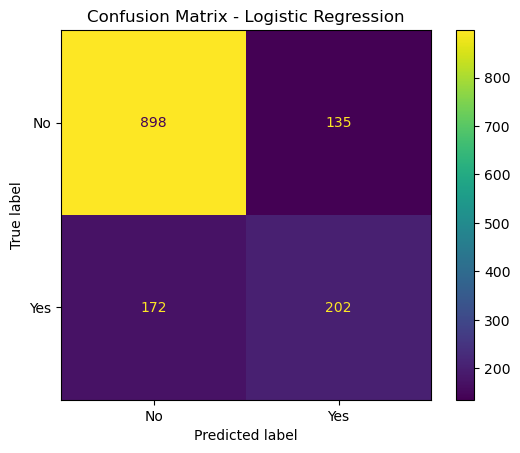

In [23]:
# ==========================================================
# Q2(b) Baseline Model Development
# Step 7: Display Confusion Matrix
# ==========================================================

ConfusionMatrixDisplay.from_estimator(
    baseline_model,
    X_test,
    y_test
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## Q2(c) Improved Model Development

### Random Forest Classifier

In [25]:
from sklearn.ensemble import RandomForestClassifier

In [30]:
# ==========================================================
# Q2(c) Improved Model Development - Build Random Forest Model
# ==========================================================

from sklearn.ensemble import RandomForestClassifier

# Create Improved Random Forest pipeline
improved_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

# Train the improved model
improved_model.fit(X_train, y_train)

print("Improved Random Forest model trained successfully.")

Improved Random Forest model trained successfully.


In [31]:
y_pred_rf = improved_model.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


In [32]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Model Accuracy:", round(accuracy_rf, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Model Accuracy: 0.737

Classification Report:
              precision    recall  f1-score   support

          No       0.90      0.73      0.80      1033
         Yes       0.50      0.77      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.74      0.75      1407



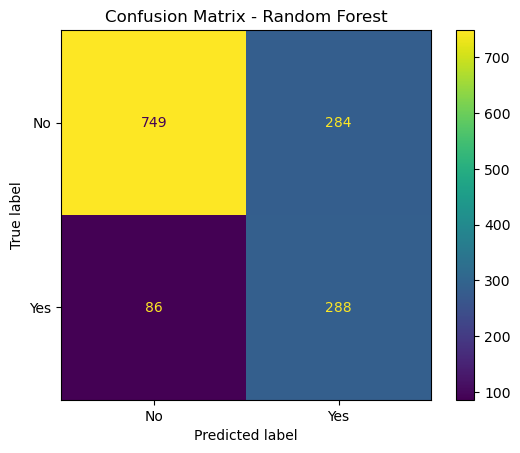

In [33]:
ConfusionMatrixDisplay.from_estimator(
    improved_model,
    X_test,
    y_test
)

plt.title("Confusion Matrix - Random Forest")
plt.show()

# Q3. Automation, Version Control and CI/CD

In [35]:
# ==========================================================
# Q3(a) Automated Validation Script
# ==========================================================

def validate_data(df):

    # Check missing values
    print("=" * 50)
    print("Missing Values")
    print("=" * 50)
    print(df.isnull().sum()[df.isnull().sum() > 0])

    # Check duplicate records
    print("\n" + "=" * 50)
    print("Duplicate Records")
    print("=" * 50)
    print(df.duplicated().sum())

    # Check data types
    print("\n" + "=" * 50)
    print("Data Types")
    print("=" * 50)
    print(df.dtypes)

    # Check target values
    print("\n" + "=" * 50)
    print("Unique Values in Churn Label")
    print("=" * 50)
    print(df["Churn Label"].unique())

# Run validation
validate_data(df)

Missing Values
Churn Reason    5163
dtype: int64

Duplicate Records
0

Data Types
CustomerID               str
Count                  int64
Country                  str
State                    str
City                     str
Zip Code               int64
Lat Long                 str
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges        float64
Churn Label              str
Churn Value            int64
Churn Score            int64
CLTV               

GitHub was used to manage the project using version control.

Repository and commit history screenshots are included in the report as evidence of Agile development and version tracking.

## Q3(c) Automated Testing and CI/CD